In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
from IPython.display import clear_output
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 16
    epochs = 10
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x


class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.double_conv(x)
        x = self.pool(skip)
        return x, skip


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.double_conv = ConvBlock(out_channels * 2, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        x = self.double_conv(x)
        return x

In [4]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)
        self.bottleneck = ConvBlock(512, 1024)
        self.dec4 = DecoderBlock(1024, 512)
        self.dec3 = DecoderBlock(512, 256)
        self.dec2 = DecoderBlock(256, 128)
        self.dec1 = DecoderBlock(128, 64)
        self.conv = nn.Conv2d(64, out_channels, kernel_size=1)


    def forward(self, x):
        x, skip1 = self.enc1(x)
        x, skip2 = self.enc2(x)
        x, skip3 = self.enc3(x)
        x, skip4 = self.enc4(x)
        x = self.bottleneck(x)
        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)

        x = self.conv(x)

        return x

In [5]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [6]:
class Trainer:
    def __init__(self, config, model=UNet):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        self.model = model().to(self.config.device)
        self.criterion = nn.BCEWithLogitsLoss() # какой лосс удобный возьмем для бинарной сегментации?
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        total_train, total_val, total_iou, total_f1 = [], [], [], []
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")
            total_train.append(train_loss)
            total_val.append(val_loss)
            total_iou.append(val_iou)
            total_f1.append(val_f1)

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")
        return total_train, total_val, total_iou, total_f1

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader, leave=False, desc="train"):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader, leave=False, desc="val"):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader, leave=False, desc="test"):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [7]:
def show_info(train_loss, val_loss, val_iou, val_f1):
    epochs = [(i + 1) for i in range(len(train_loss))]
    plt.figure(figsize=(16,9))
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_loss, label='train loss')
    plt.plot(epochs, val_loss, label='val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, val_iou, label='IoU')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.title('IoU')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, val_f1, label='F1-score')
    plt.xlabel('Epoch')
    plt.ylabel('F1-score')
    plt.title('F1-score')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.show()

In [45]:
trainer = Trainer(config)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [46]:
class_total_train, class_total_val, class_total_iou, class_total_f1 = trainer.run()

Epoch 1 / 10, Train Loss: 0.4432, Val Loss: 0.4204, Val IoU: 0.7567, Val F1-score: 0.8549


Epoch 2 / 10, Train Loss: 0.3866, Val Loss: 0.3910, Val IoU: 0.7727, Val F1-score: 0.8648


Epoch 3 / 10, Train Loss: 0.3521, Val Loss: 0.3432, Val IoU: 0.8058, Val F1-score: 0.8858


Epoch 4 / 10, Train Loss: 0.3112, Val Loss: 0.3182, Val IoU: 0.8211, Val F1-score: 0.8950


Epoch 5 / 10, Train Loss: 0.2860, Val Loss: 0.2906, Val IoU: 0.8333, Val F1-score: 0.9031


...

Epoch 7 / 10, Train Loss: 0.2484, Val Loss: 0.2909, Val IoU: 0.8403, Val F1-score: 0.9067


Epoch 8 / 10, Train Loss: 0.2363, Val Loss: 0.2645, Val IoU: 0.8502, Val F1-score: 0.9135


Epoch 9 / 10, Train Loss: 0.2213, Val Loss: 0.2329, Val IoU: 0.8604, Val F1-score: 0.9203


Epoch 10 / 10, Train Loss: 0.2095, Val Loss: 0.2239, Val IoU: 0.8621, Val F1-score: 0.9210
Testing...


Test Loss: 0.2217, Test IoU: 0.8666, Test F1-score: 0.9230


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].


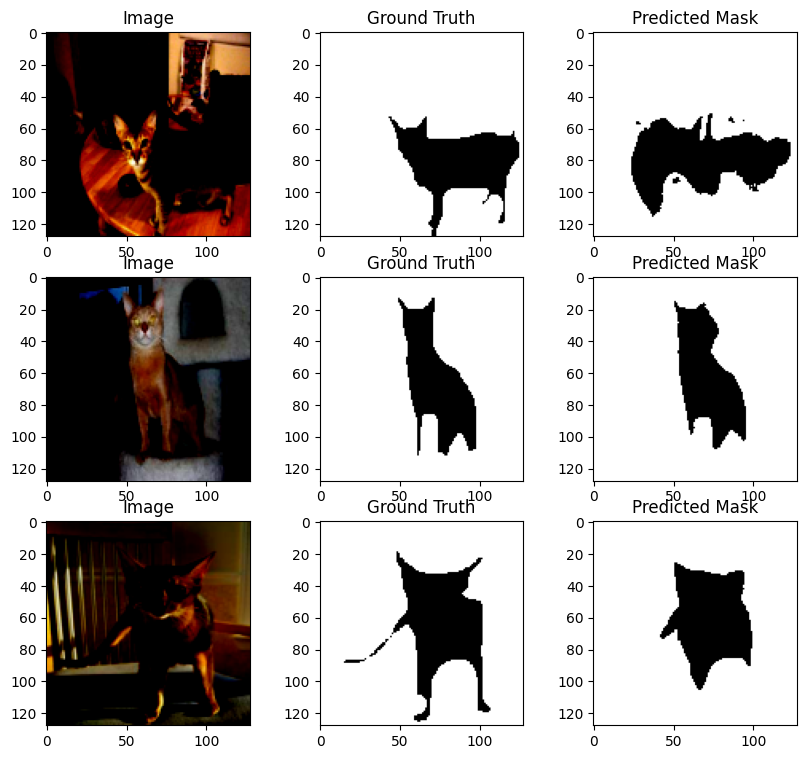

In [47]:
trainer.inference_and_plot_samples(n_samples=3)

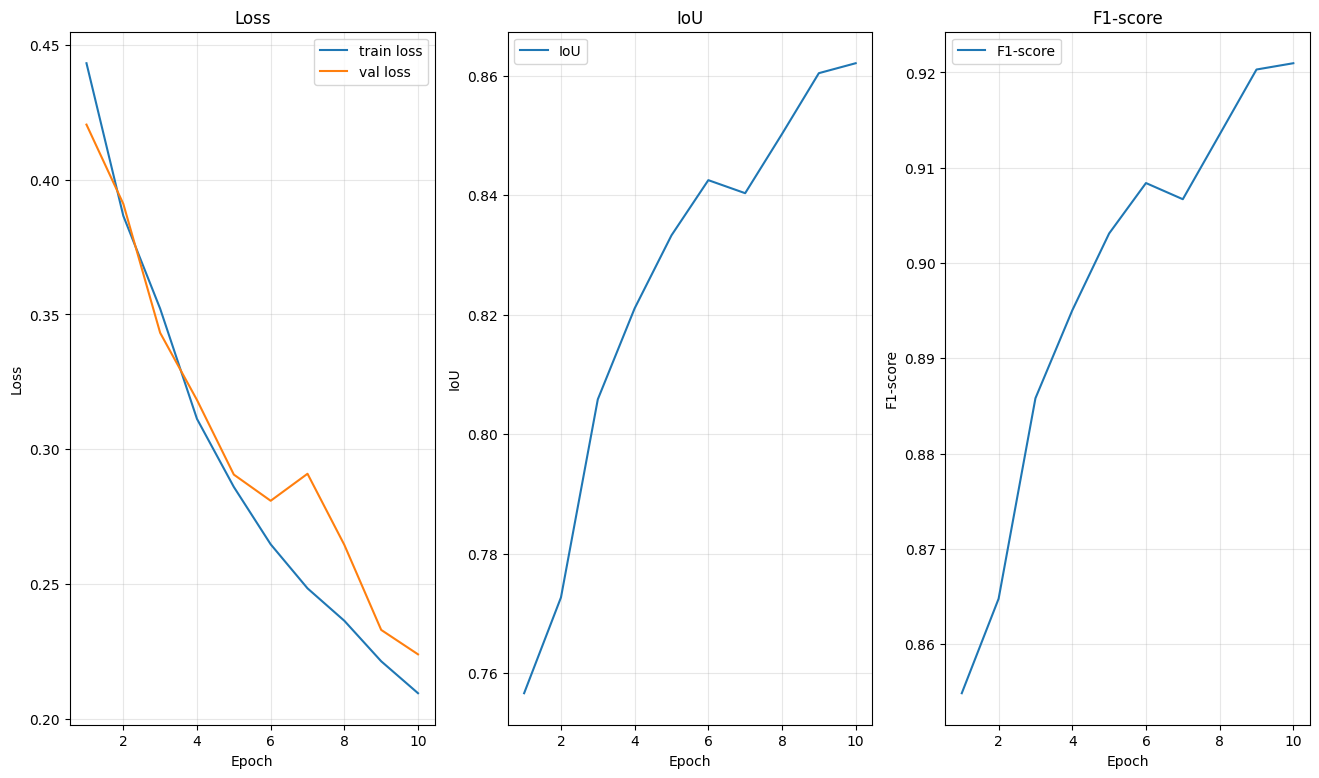

In [48]:
show_info(class_total_train, class_total_val, class_total_iou, class_total_f1)

In [ ]:
from itertools import product


def make_config(base_config, lr, batch_size, epochs):
    cfg = Config()
    cfg.image_size = base_config.image_size
    cfg.batch_size = batch_size
    cfg.epochs = epochs
    cfg.learning_rate = lr
    cfg.device = base_config.device
    cfg.train_split = base_config.train_split
    return cfg


def clone_state_dict_to_cpu(state_dict):
    return {k: v.detach().cpu().clone() for k, v in state_dict.items()}


def run_one_experiment(cfg):
    np.random.seed(42)
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)
    trainer = Trainer(cfg)
    train_loss, val_loss, val_iou, val_f1 = trainer.run()

    history = {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_iou": val_iou,
        "val_f1": val_f1,
    }


    best_state_dict = clone_state_dict_to_cpu(trainer.model.state_dict())
    result = {
        "learning_rate": cfg.learning_rate,
        "batch_size": cfg.batch_size,
        "epochs": cfg.epochs,
        "seed": cfg.seed,
        "history": history,
        "best_val_iou": history["val_iou"][-1],
        "best_val_f1": history["val_f1"][-1],
        "best_val_loss": history["val_loss"][-1],
        "best_state_dict": best_state_dict,
    }

    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


def run_selection(base_config, learning_rates, batch_sizes, epochs=5, seed=42):
    results = []
    total_runs = len(learning_rates) * len(batch_sizes)

    for run_id, (lr, bs) in enumerate(product(learning_rates, batch_sizes), start=1):
        clear_output(wait=True)
        print(f"Run {run_id}/{total_runs}: lr={lr}, batch_size={bs}")

        cfg = make_config(base_config, lr=lr, batch_size=bs, epochs=epochs, seed=seed)
        result = run_one_experiment(cfg)
        results.append(result)

        print(
            f"Best: val_iou={result['best_val_iou']:.4f}, "
            f"val_f1={result['best_val_f1']:.4f}, "
        )

    results.sort(key=lambda x: x["best_val_iou"], reverse=True)
    return results


def print_ranked_results(results):
    print("\nRanking by best validation IoU:\n")
    for i, r in enumerate(results):
        print(
            f"{i + 1:02d}. lr={r['learning_rate']:<7},"
            f"batch_size={r['batch_size']:<2},"
            f"best_val_iou={r['best_val_iou']:.4f},"
            f"best_val_f1={r['best_val_f1']:.4f}, "
        )


def plot_metric_heatmap(results, learning_rates, batch_sizes, metric_key, title):
    grid = np.zeros((len(learning_rates), len(batch_sizes)))

    for i, lr in enumerate(learning_rates):
        for j, bs in enumerate(batch_sizes):
            match = next(
                r for r in results
                if r["learning_rate"] == lr and r["batch_size"] == bs
            )
            grid[i, j] = match[metric_key]

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(grid, cmap="viridis")

    ax.set_xticks(range(len(batch_sizes)))
    ax.set_xticklabels(batch_sizes)
    ax.set_yticks(range(len(learning_rates)))
    ax.set_yticklabels(learning_rates)

    ax.set_xlabel("Batch size")
    ax.set_ylabel("Learning rate")
    ax.set_title(title)

    for i in range(len(learning_rates)):
        for j in range(len(batch_sizes)):
            ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="white")

    plt.colorbar(im, ax=ax)
    plt.show()


def plot_best_history(best_result):
    history = best_result["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], marker="o", label="train loss")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="val loss")
    axes[0].set_title("Loss curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history["val_iou"], marker="o", label="val IoU")
    axes[1].plot(epochs, history["val_f1"], marker="o", label="val F1")
    axes[1].set_title("Validation metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Run 9/9: lr=0.001, batch_size=32


Epoch 1 / 5, Train Loss: 0.4605, Val Loss: 0.3924, Val IoU: 0.7765, Val F1-score: 0.8686


Epoch 2 / 5, Train Loss: 0.3657, Val Loss: 0.3715, Val IoU: 0.8122, Val F1-score: 0.8903


Epoch 3 / 5, Train Loss: 0.3201, Val Loss: 0.2997, Val IoU: 0.8295, Val F1-score: 0.9023


Epoch 4 / 5, Train Loss: 0.2837, Val Loss: 0.2726, Val IoU: 0.8416, Val F1-score: 0.9096


Epoch 5 / 5, Train Loss: 0.2593, Val Loss: 0.2543, Val IoU: 0.8518, Val F1-score: 0.9155
Testing...


Test Loss: 0.2570, Test IoU: 0.8465, Test F1-score: 0.9107
Best: val_iou=0.8518, val_f1=0.9155, 

Ranking by best validation IoU:

01. lr=0.0001 ,batch_size=8 ,best_val_iou=0.8823,best_val_f1=0.9341, 
02. lr=0.0001 ,batch_size=16,best_val_iou=0.8731,best_val_f1=0.9285, 
03. lr=0.0001 ,batch_size=32,best_val_iou=0.8622,best_val_f1=0.9221, 
04. lr=0.001  ,batch_size=8 ,best_val_iou=0.8535,best_val_f1=0.9173, 
05. lr=0.001  ,batch_size=32,best_val_iou=0.8518,best_val_f1=0.9155, 
06. lr=1e-05  ,batch_size=8 ,best_val_iou=0.8497,best_val_f1=0.9146, 
07. lr=0.001  ,batch_size=16,best_val_iou=0.8462,best_val_f1=0.9126, 
08. lr=1e-05  ,batch_size=32,best_val_iou=0.8315,best_val_f1=0.9036, 
09. lr=1e-05  ,batch_size=16,best_val_iou=0.8101,best_val_f1=0.8901, 


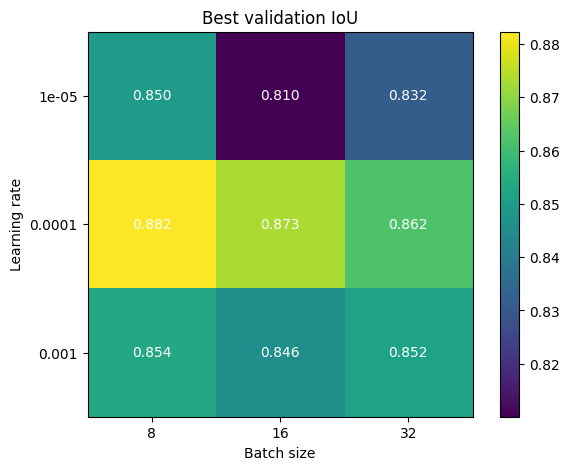

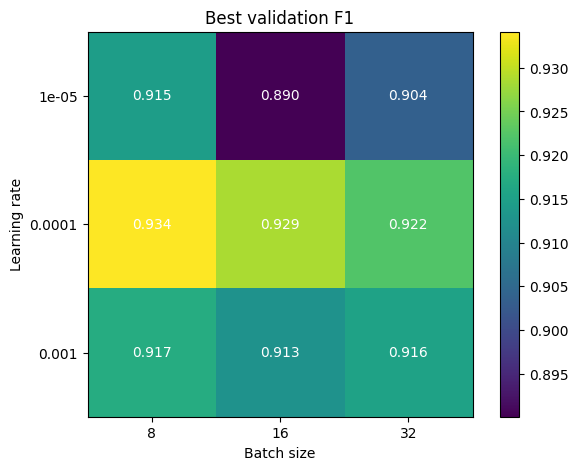

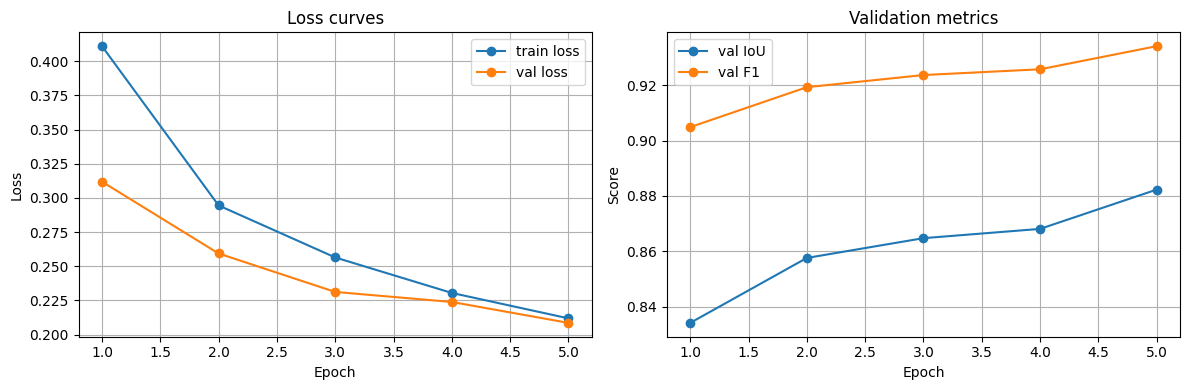

In [9]:
learning_rates = [1e-5, 1e-4, 1e-3]
batch_sizes = [8, 16, 32]

results = run_selection(
    base_config=config,
    learning_rates=learning_rates,
    batch_sizes=batch_sizes,
)

print_ranked_results(results)

plot_metric_heatmap(results, learning_rates, batch_sizes, "best_val_iou", "Best validation IoU")
plot_metric_heatmap(results, learning_rates, batch_sizes, "best_val_f1", "Best validation F1")

best_result = results[0]
plot_best_history(best_result)


In [32]:
best_cfg = make_config(
    config,
    lr=best_result["learning_rate"],
    batch_size=best_result["batch_size"],
    epochs=best_result["epochs"],
    seed=best_result["seed"]
)

best_trainer = Trainer(best_cfg)
best_trainer.model.load_state_dict(best_result["best_state_dict"])

test_loss, test_iou, test_f1 = best_trainer.test()
print(f"Test Loss: {test_loss:.4f}, Test IoU: {test_iou:.4f}, Test F1: {test_f1:.4f}")


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 459/459 [00:41<00:00, 11.03it/s]

Test Loss: 0.2120, Test IoU: 0.8758, Test F1: 0.9292


Судя по хитмапам, лучшим оказлась сборка с lr = 0.0001 и batch size = 8. Данный lr оптимален для сборки, он дал лучший баланс, скорости обучения и его устойчивостью.

Минимальный батч сайз сделал градиенты более шумными и поэтому модель стала лучше обощать во время обучения.

# Улучшаем UNet
Попробуем сгруппировать наши выходные каналы и сделать нормализацию по этим группам

In [37]:
def group_norm(num_channels, num_groups=8):
    groups = min(num_groups, num_channels)
    while num_channels % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, num_channels)
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_groups=8):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.gn1 = group_norm(out_channels, num_groups)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.gn2 = group_norm(out_channels, num_groups)

    def forward(self, x):
        x = self.conv1(x)
        x = self.gn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.gn2(x)
        x = self.relu(x)
        return x


class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_groups=8):
        super().__init__()
        self.double_conv = ConvBlock(in_channels, out_channels, num_groups)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.double_conv(x)
        x = self.pool(skip)
        return x, skip


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_groups=8):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.double_conv = ConvBlock(out_channels * 2, out_channels, num_groups)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        x = self.double_conv(x)
        return x

In [38]:
class NewUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_groups=8):
        super(NewUNet, self).__init__()

        self.enc1 = EncoderBlock(in_channels, 64, num_groups)
        self.enc2 = EncoderBlock(64, 128, num_groups)
        self.enc3 = EncoderBlock(128, 256, num_groups)
        self.enc4 = EncoderBlock(256, 512, num_groups)
        self.bottleneck = ConvBlock(512, 1024, num_groups)
        self.dec4 = DecoderBlock(1024, 512, num_groups)
        self.dec3 = DecoderBlock(512, 256, num_groups)
        self.dec2 = DecoderBlock(256, 128, num_groups)
        self.dec1 = DecoderBlock(128, 64, num_groups)
        self.conv = nn.Conv2d(64, out_channels, kernel_size=1)


    def forward(self, x):
        x, skip1 = self.enc1(x)
        x, skip2 = self.enc2(x)
        x, skip3 = self.enc3(x)
        x, skip4 = self.enc4(x)
        x = self.bottleneck(x)
        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)

        x = self.conv(x)

        return x

In [39]:
newtrainer = Trainer(config, model=NewUNet)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [40]:
total_train, total_val, total_iou, total_f1 = newtrainer.run()

Epoch 1 / 10, Train Loss: 0.4468, Val Loss: 0.4140, Val IoU: 0.7595, Val F1-score: 0.8571


Epoch 2 / 10, Train Loss: 0.3876, Val Loss: 0.3631, Val IoU: 0.8013, Val F1-score: 0.8820


Epoch 3 / 10, Train Loss: 0.3508, Val Loss: 0.3238, Val IoU: 0.8170, Val F1-score: 0.8936


Epoch 4 / 10, Train Loss: 0.3146, Val Loss: 0.3081, Val IoU: 0.8250, Val F1-score: 0.8986


Epoch 5 / 10, Train Loss: 0.2834, Val Loss: 0.2695, Val IoU: 0.8503, Val F1-score: 0.9135


...

Epoch 7 / 10, Train Loss: 0.2495, Val Loss: 0.2567, Val IoU: 0.8508, Val F1-score: 0.9146


Epoch 8 / 10, Train Loss: 0.2415, Val Loss: 0.2394, Val IoU: 0.8636, Val F1-score: 0.9220


Epoch 9 / 10, Train Loss: 0.2249, Val Loss: 0.2531, Val IoU: 0.8606, Val F1-score: 0.9193


Epoch 10 / 10, Train Loss: 0.2144, Val Loss: 0.2337, Val IoU: 0.8610, Val F1-score: 0.9210
Testing...


Test Loss: 0.2375, Test IoU: 0.8594, Test F1-score: 0.9195


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..1.0].


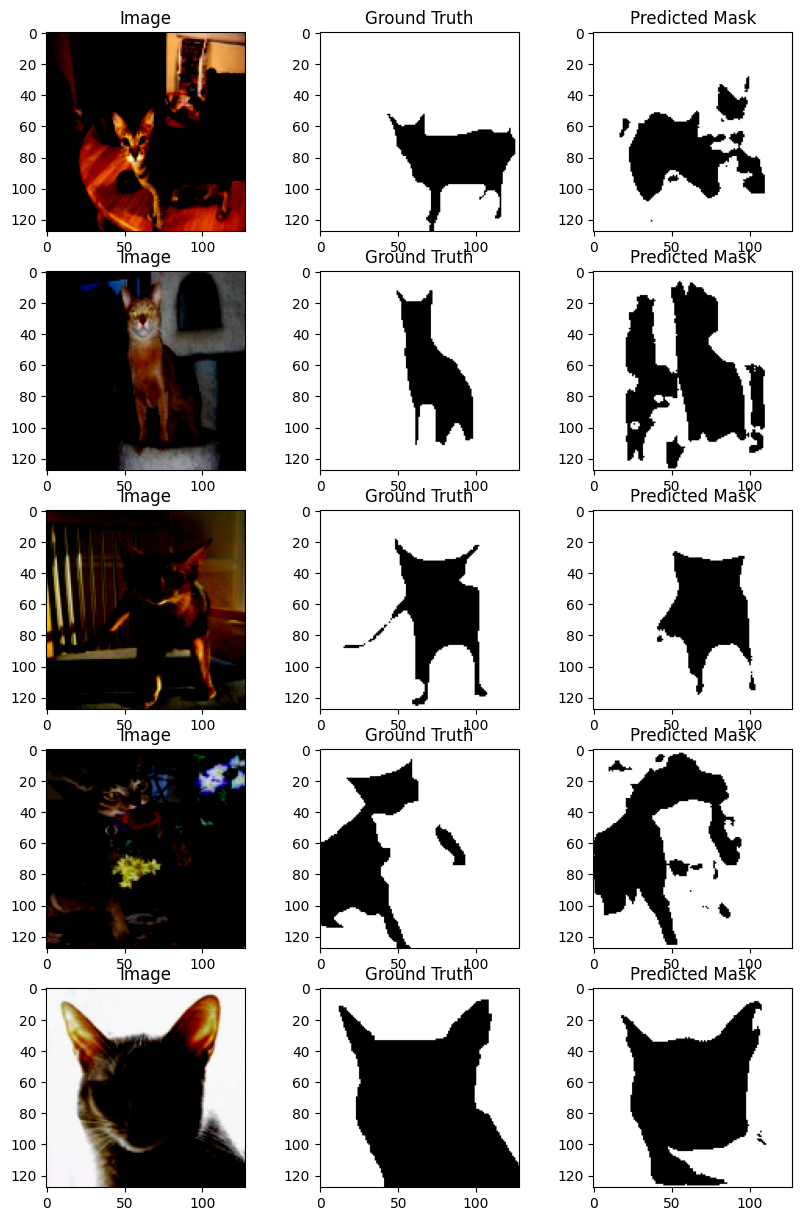

In [44]:
newtrainer.inference_and_plot_samples(n_samples=5)

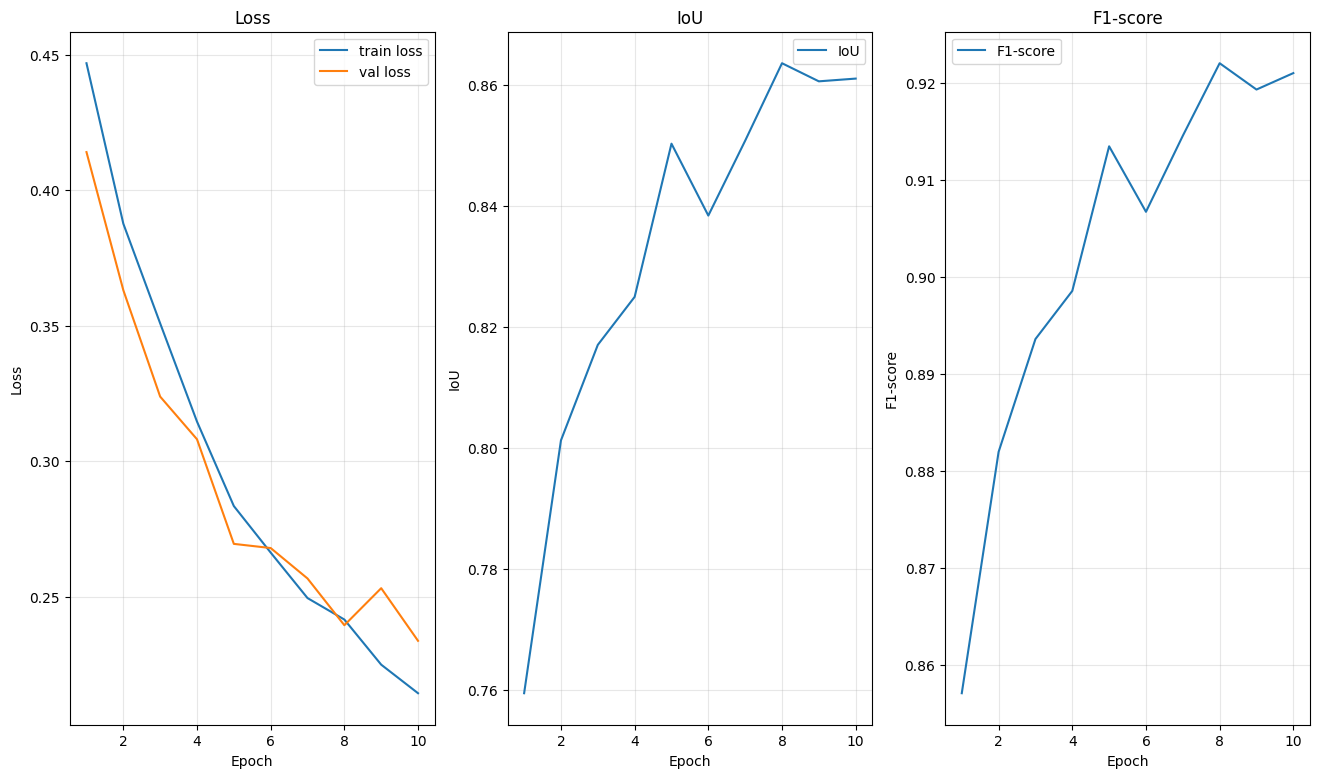

In [42]:
show_info(total_train, total_val, total_iou, total_f1)

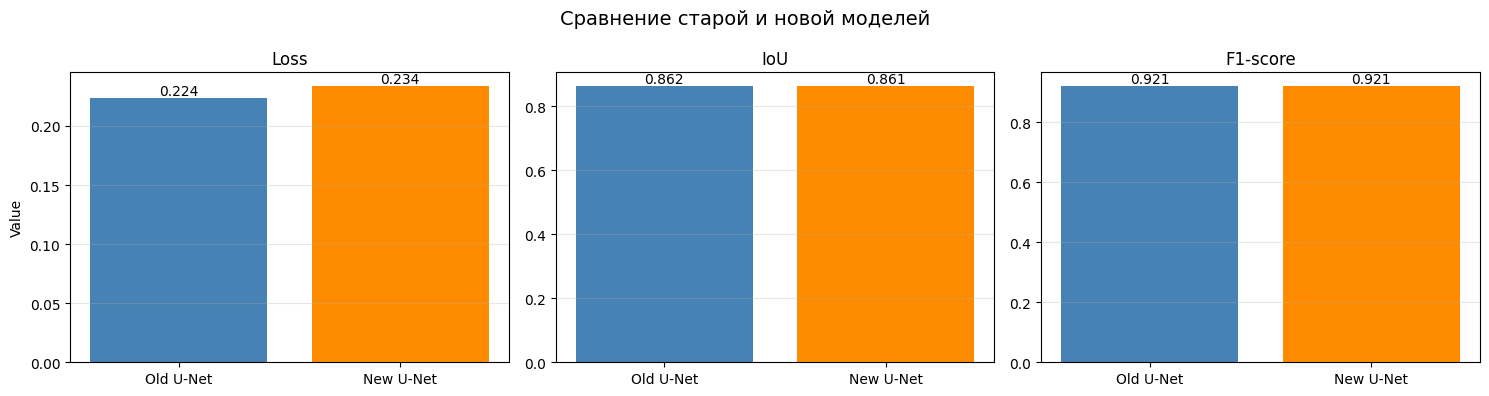

In [52]:
models = ["Old U-Net", "New U-Net"]
losses = [class_total_val[-1], total_val[-1]]
ious = [class_total_iou[-1], total_iou[-1]]
f1s = [class_total_f1[-1], total_f1[-1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

bars1 = axes[0].bar(models, losses, color=["steelblue", "darkorange"])
axes[0].set_title("Loss")
axes[0].set_ylabel("Value")
axes[0].grid(axis="y", alpha=0.3)

bars2 = axes[1].bar(models, ious, color=["steelblue", "darkorange"])
axes[1].set_title("IoU")
axes[1].grid(axis="y", alpha=0.3)

bars3 = axes[2].bar(models, f1s, color=["steelblue", "darkorange"])
axes[2].set_title("F1-score")
axes[2].grid(axis="y", alpha=0.3)


def add_labels(ax, bars):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom"
        )

add_labels(axes[0], bars1)
add_labels(axes[1], bars2)
add_labels(axes[2], bars3)

fig.suptitle("Сравнение старой и новой моделей", fontsize=14)
plt.tight_layout()
plt.show()

Нормировка по группам не дала никаких результатов, разница между метриками пренебрежительно мала